In [2]:
import seaborn as sns
import xarray as xr
import numpy as np
import gsw
from matplotlib import cm
import matplotlib.pyplot as plt
import matplotlib as mpl
import cmocean
from matplotlib.animation import FuncAnimation
from matplotlib import animation
import ffmpeg
import pylab as pl
import pandas as pd
from math import radians, cos
from matplotlib.gridspec import GridSpec
import matplotlib as mpl

In [56]:
project='2tracers'
ed='run5/'

directory='/Users/ameliameggo/Proyecto/Codigo/NGC/'+ str(project)
dataloc=str(directory)+ '/' + str(ed)
location= str(directory) + '/Files/' + str(ed) #'/Users/ameliaking/Proyecto/Codigo/Idealizada/ChangeDim/'

#location='/home/amelia/NGC/'+ str(project) + '/Files/' + str(ed) #'/Users/ameliaking/Proyecto/Codigo/Idealizada/ChangeDim/'

if project=='realBathy':
    if ed == 'run2/' or ed == 'run5/' or ed == 'run4/':
        ds=xr.open_dataset(str(location) + 'theta.nc')
        dsVVEL=xr.open_dataset(str(location) + 'vvel.nc')
        dsWVEL=xr.open_dataset(str(location) + 'wvel.nc')
        dsUVEL=xr.open_dataset(str(location) + 'uvel.nc')
    elif ed == 'run7/':
        var='dynDiagLeithD3ViscA4'
        ds=xr.open_dataset(str(location) +  str(var) + '.nc')
    else:
        for i in np.arange(10,60,10):
            var='dynDiag'+str(i)
            if i==10:
                ds=xr.open_dataset(str(location) +  str(var) + '.nc')
            else:
                ds=ds.merge(xr.open_dataset(str(location) +  str(var) + '.nc'))
else:
    var='dynDiag'
    ds=xr.open_dataset(str(location) +  str(var) + '.nc')
    
#varT='THETA'

#dsT=xr.open_dataset(str(location) +  str(varT) + '.nc')

varS='surfDiag'

#dsS=xr.open_dataset(str(location) +  str(varS) + '.nc')

varG='grid'

dsG=xr.open_dataset(str(location) +  str(varG) + '.nc')


#Take them minus 1 and 2 to skip the boundary
ny=len(dsG.Y)
nx=len(dsG.X) 
nz=len(dsG.Z)
nt=len(ds.T) 

if project=='twoBumps' or project=='2tracers':
    umbral1=np.where(dsG.Depth[:int(ny/2),20].values==np.min(dsG.Depth[:int(ny/2),20].values))[0][int(len(np.where(dsG.Depth[:int(ny/2),20].values==np.min(dsG.Depth[:int(ny/2),20].values))[0])/2)]
    umbral2=np.where(dsG.Depth[int(ny/2):,20].values==np.min(dsG.Depth[int(ny/2):,20].values))[0][int(len(np.where(dsG.Depth[int(ny/2):,20].values==600)[0])/2)]+int(ny/2)

    umbralEnd1=np.where(dsG.Depth[:int(ny/2),20]<np.max(dsG.Depth[:int(ny/2),20]))[0][-1]
    umbralEnd2=np.where(dsG.Depth[int(ny/2):,20]<np.max(dsG.Depth[int(ny/2):,20]))[0][-1]+int(ny/2)
else:
    umbral=np.where(dsG.Depth[:-1,20].values==np.min(dsG.Depth[:-1,20].values))[0][int(len(np.where(dsG.Depth[:,20].values==np.min(dsG.Depth[:,20].values))[0])/2)]
    umbralEnd=np.where(dsG.Depth[:,20]<np.max(dsG.Depth[:,20]))[0][-1]

hFacC = dsG.HFacC

hfa = np.ma.masked_values(hFacC, 0)
mask = np.ma.getmask(hfa)

hFacW = dsG.HFacW

hfaW = np.ma.masked_values(hFacW, 0)
maskw = np.ma.getmask(hfaW)

hFacS = dsG.HFacS

hfaS = np.ma.masked_values(hFacS, 0)
masks = np.ma.getmask(hfaS)

#info=pd.read_csv(str(dataloc) + 'data',sep='/n')
#parameters=['viscAh','viscAr','diffKhT','diffKrT']


if project == '2Dsill':
    OB=1
    OBend=-1
elif project =='2DsillOB':
    OBp=1
    OBendp=-1
    OB=21
    OBend=-1
elif project =='OpenNorth' or project =='Orlanski':
    OBp=1
    OBendp=-1
    OB=10
    OBend=-10
    OBx=1
    OBendx=-1
else:
    OBp=1
    OBendp=-1
    OB=20
    OBend=-20
    OBx=1
    OBendx=-1

In [57]:
closS=1 #int(len(dsG.Y)*0.4)
closE=-1#np.where(dsG.Y>=130000)[0][0] #np.where(dsG.Y>=260000)[0][0]
depS=np.where(dsG.Z>=-400)[0][-1]
depE=np.where(dsG.Z>=-700)[0][-1]

In [58]:
umbral1=np.where(dsG.Depth[:int(ny/2),20].values==np.min(dsG.Depth[:int(ny/2),20].values))[0][int(len(np.where(dsG.Depth[:int(ny/2),20].values==np.min(dsG.Depth[:int(ny/2),20].values))[0])/2)]+1
umbral2=np.where(dsG.Depth[int(ny/2):-int(ny/4),20].values==np.min(dsG.Depth[int(ny/2):-int(ny/4),20].values))[0][int(len(np.where(dsG.Depth[int(ny/2):-int(ny/4),20].values==600)[0])/2)]+int(ny/2)+1
umbral3=np.where(dsG.Depth[-int(ny/4):,20].values==np.min(dsG.Depth[-int(ny/4):,20].values))[0][0]+(len(dsG.Depth[:,0])-int(ny/4))-10


umbralEnd1=np.where(dsG.Depth[:int(ny/2),20]==np.max(dsG.Depth[:int(ny/2),20]))[0][0]
umbralEnd2=np.where(dsG.Depth[int(ny/2):,20]<np.max(dsG.Depth[int(ny/2):,20]))[0][-1]+int(ny/2)

In [59]:
params = {'font.size': 15,
          'figure.figsize': (10, 12),
         'font.family':'sans'}
pl.rcParams.update(params)
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

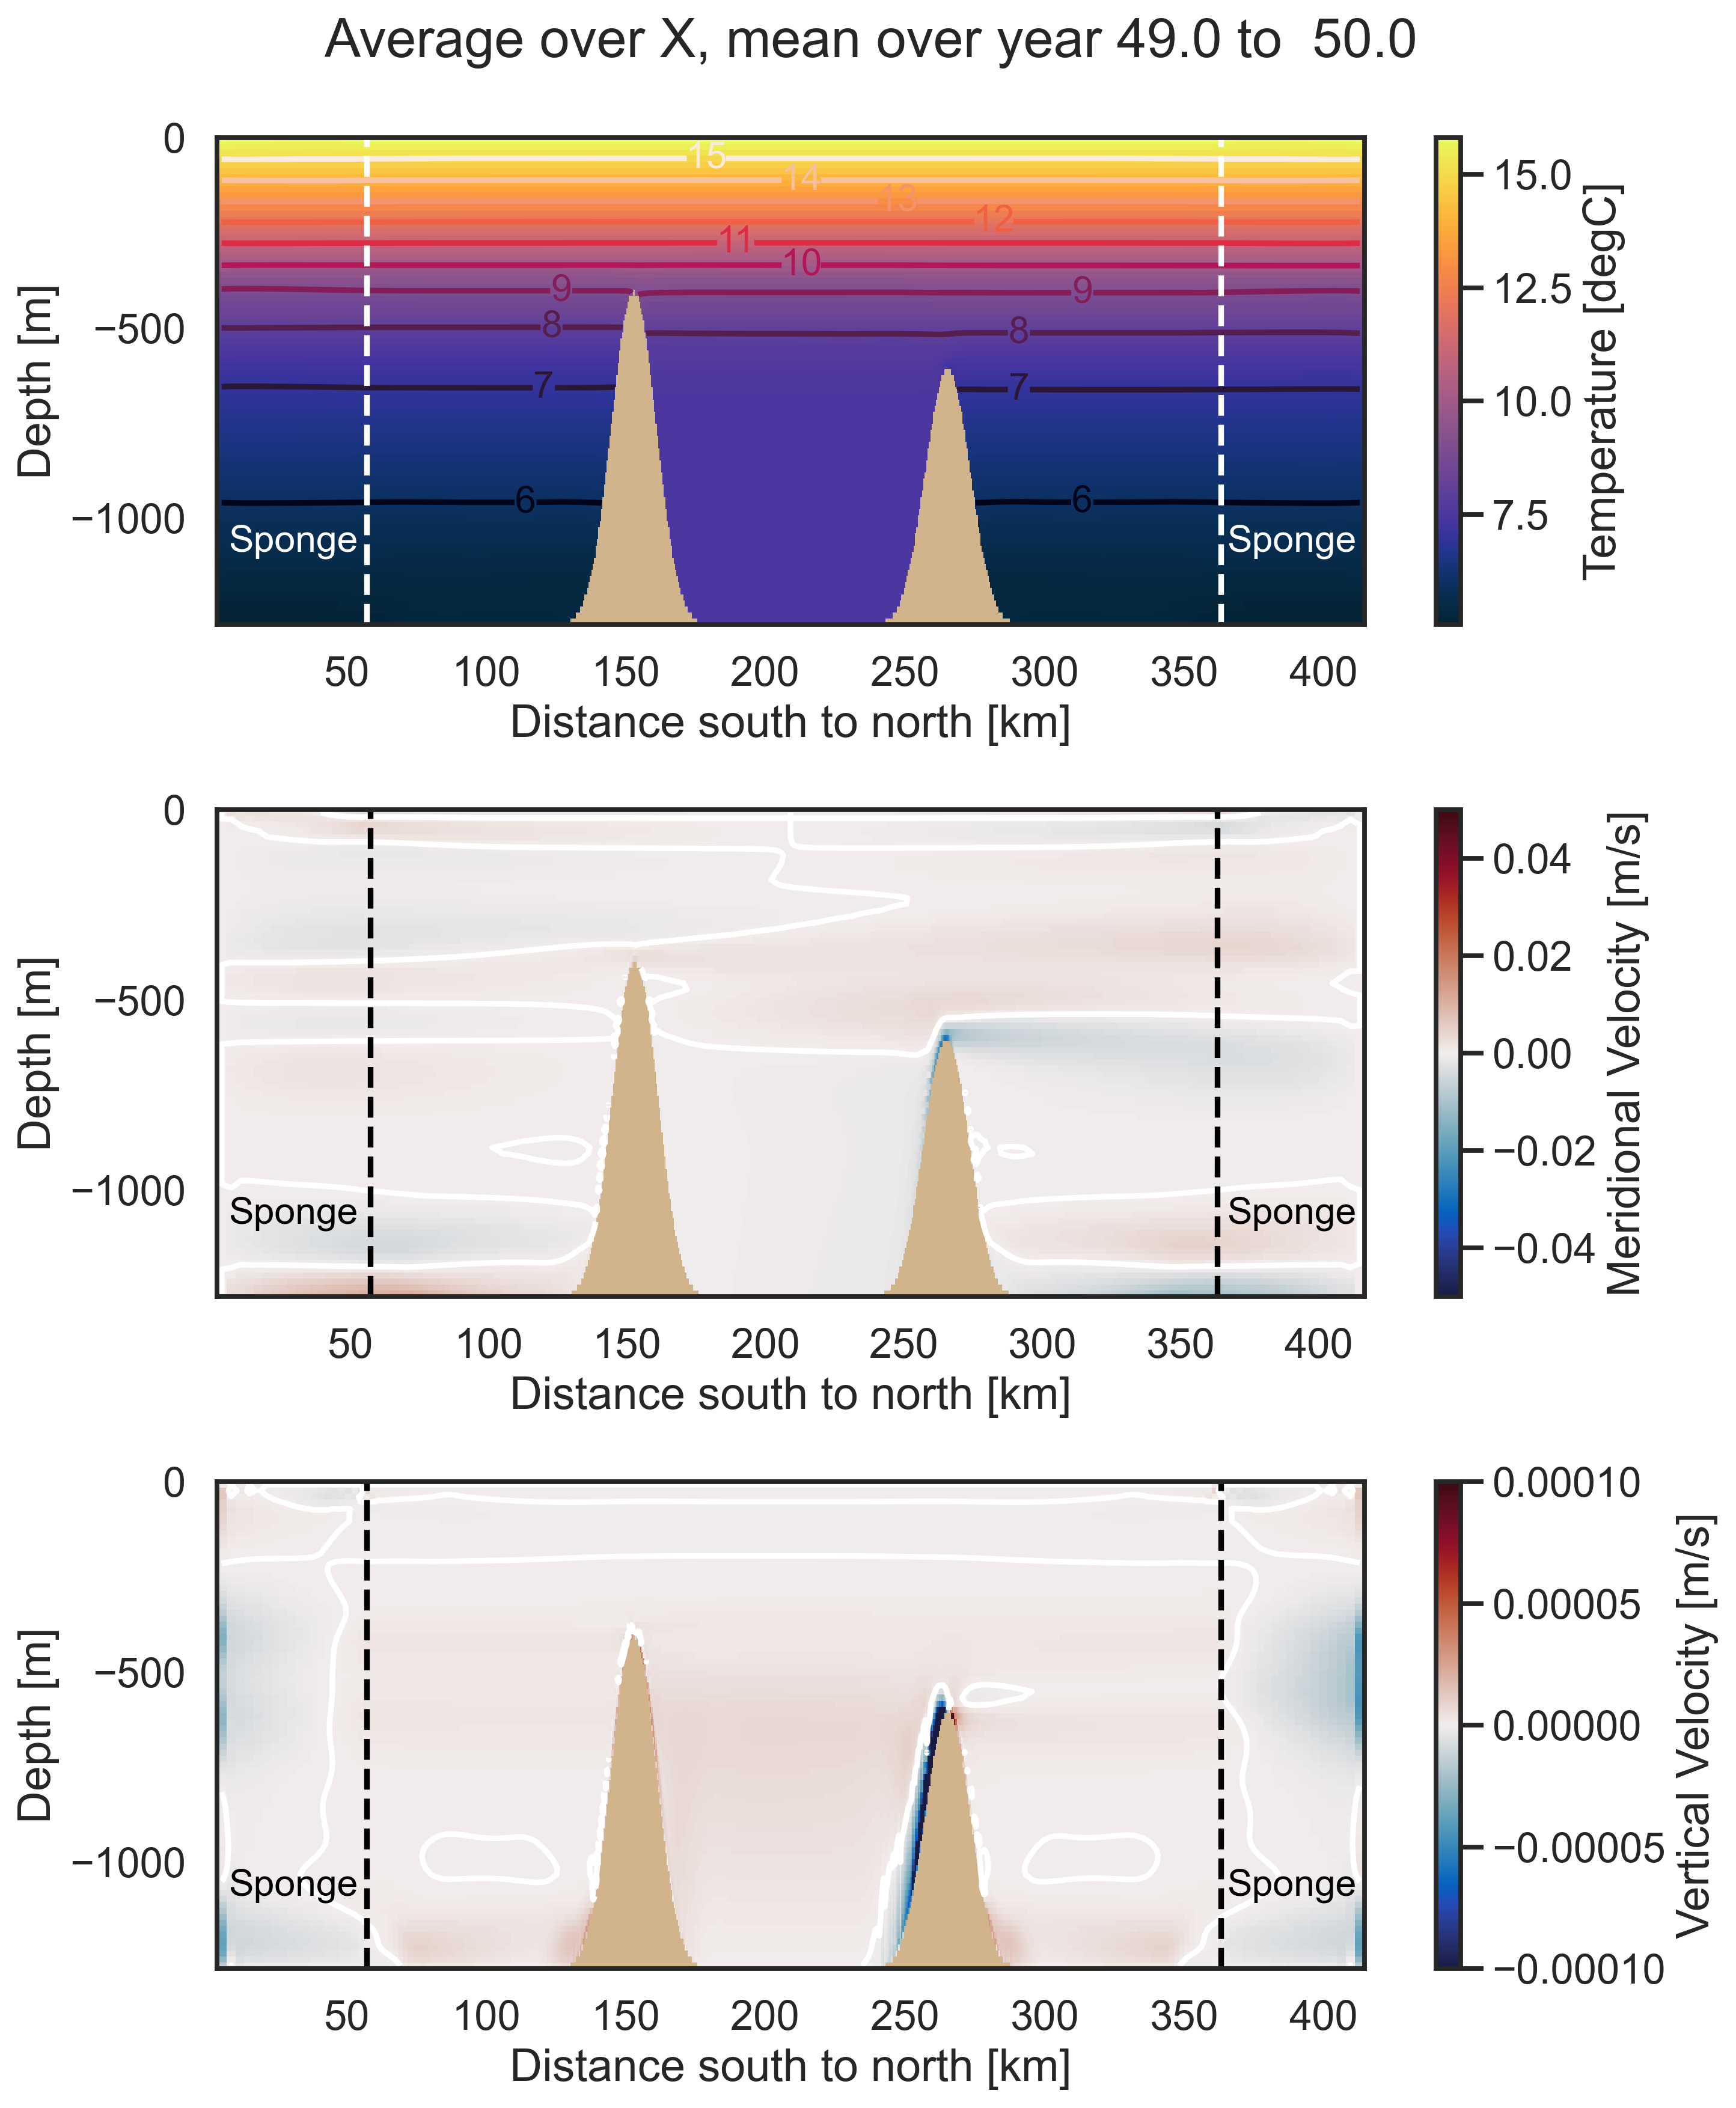

In [61]:
indX=np.arange(OBx,len(dsG.X)-1,1) #-2#1 #int(nx/2)
tin=np.arange(-3,0,1)
vmin=np.min(np.mean(np.ma.masked_array(np.mean(ds.THETA[tin,:,closS:closE,indX],axis=0),mask=mask[:,closS:closE,indX]),axis=2))
vmax=np.max(np.mean(np.ma.masked_array(np.mean(ds.THETA[tin,:,closS:closE,indX],axis=0),mask=mask[:,closS:closE,indX]),axis=2))

sns.set_theme(context="talk",style='white')

fig,ax=plt.subplots(3)
axin=ax[0]
cax=axin.pcolormesh(dsG.Y[closS:closE]/1000,dsG.Z,np.mean(np.ma.masked_array(np.mean(ds.THETA[tin,:,closS:closE,indX],axis=0),mask=mask[:,closS:closE,indX]),axis=2),vmin=vmin,vmax=vmax,cmap=cmocean.cm.thermal)
levels=[6,7,8,9,10,11,12,13,14,15]
caxC=axin.contour(dsG.Y[closS:closE]/1000,dsG.Z,np.mean(np.ma.masked_array(np.mean(ds.THETA[tin,:,closS:closE,indX],axis=0),mask=mask[:,closS:closE,indX]),axis=2),levels=levels)
axin.clabel(caxC, inline=1, fontsize='small')
axin.set_facecolor('tan')

axin.axvline(dsG.Y[OB]/1000,c='white',linestyle='dashed')
axin.text(0.01, 0.15, 'Sponge', color='white', 
    transform=axin.transAxes,fontsize='small')
axin.axvline(dsG.Y[OBend]/1000,c='white',linestyle='dashed')
axin.text(0.88, 0.15, 'Sponge', color='white', 
    transform=axin.transAxes,fontsize='small')
'''
if tin==-2:
    axin.axvline(dsG.Y[locmin]/1000,color='red',linestyle='dashed')

    axin.text(0.52, 0.15, f'Location of surface\nminimum temperature\nAt {dsG.Y[locmin]/1000:.1f} km', color='red', 
        transform=axin.transAxes)
if tin==-1:
    axin.axvline(dsG.Y[locmax]/1000,color='red',linestyle='dashed')

    axin.text(0.52, 0.15, f'Location of surface\nmaximum temperature\nAt {dsG.Y[locmax]/1000:.1f} km', color='red', 
        transform=axin.transAxes)
'''
#axin.axvline(dsG.Y[locmax]/1000,color='red')

#axin.axvline(dsG.Y[umbral2]/1000)

axin.set(xlabel='Distance south to north [km]',ylabel='Depth [m]')
    
cbar=plt.colorbar(cax)
cbar.set_label('Temperature [degC]')

axin=ax[1]
axin.set_facecolor('tan')
cax=axin.pcolormesh(dsG.Yp1[closS:closE]/1000,dsG.Z,np.mean(np.ma.masked_array(np.mean(ds.VVEL[tin,:,closS:closE,indX],axis=0),mask=masks[:,closS:closE,indX]),axis=2),vmin=-0.05,vmax=0.05,cmap=cmocean.cm.balance)
axin.contour(dsG.Yp1[closS:closE]/1000,dsG.Z,np.mean(np.ma.masked_array(np.mean(ds.VVEL[tin,:,closS:closE,indX],axis=0),mask=masks[:,closS:closE,indX]),axis=2),levels=[0],colors='white')
axin.set(xlabel='Distance south to north [km]',ylabel='Depth [m]')

axin.axvline(dsG.Y[OB]/1000,c='black',linestyle='dashed')
axin.text(0.01, 0.15, 'Sponge', color='black', 
    transform=axin.transAxes,fontsize='small')
axin.axvline(dsG.Y[OBend]/1000,c='black',linestyle='dashed')
axin.text(0.88, 0.15, 'Sponge', color='black', 
    transform=axin.transAxes,fontsize='small')

cbar=plt.colorbar(cax)
cbar.set_label('Meridional Velocity [m/s]')

axin=ax[2]
cax=axin.pcolormesh(dsG.Y[closS:closE]/1000,dsG.Z,np.mean(np.ma.masked_array(np.mean(ds.WVEL[tin,:,closS:closE,indX],axis=0),mask=mask[:,closS:closE,indX]),axis=2),vmin=-0.0001,vmax=0.0001,cmap=cmocean.cm.balance)
axin.contour(dsG.Y[closS:closE]/1000,dsG.Z,np.mean(np.ma.masked_array(np.mean(ds.WVEL[tin,:,closS:closE,indX],axis=0),mask=mask[:,closS:closE,indX]),axis=2),levels=[0],colors='white')

axin.axvline(dsG.Y[OB]/1000,c='black',linestyle='dashed')
axin.text(0.01, 0.15, 'Sponge', color='black', 
    transform=axin.transAxes,fontsize='small')
axin.axvline(dsG.Y[OBend]/1000,c='black',linestyle='dashed')
axin.text(0.88, 0.15, 'Sponge', color='black', 
    transform=axin.transAxes,fontsize='small')

axin.set_facecolor('tan')
#axin.axvline(dsG.Y[umbral1]/1000,c='black',linestyle='dashed')
#axin.axvline(dsG.Y[umbral2]/1000,c='black',linestyle='dashed')
#axin.axvline(dsG.Y[umbral3]/1000,c='black',linestyle='dashed')
cbar=plt.colorbar(cax)
cbar.set_label('Vertical Velocity [m/s]')
axin.set(xlabel='Distance south to north [km]',ylabel='Depth [m]')
fig.suptitle(f'Average over X, mean over year {ds.T[tin[0]].values/(3600*24*360)} to  {ds.T[tin[-1]].values/(3600*24*360)}')
fig.tight_layout() 

plt.savefig('../' + str(project)+'/Figures/' + str(ed)+ 'MeanPresentation.png', bbox_inches='tight')